In [ ]:
! pip install transformers datasets evaluate accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

reference:
https://huggingface.co/docs/transformers/model_doc/roberta#transformers.RobertaForSequenceClassification

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
DATA_PATH = '/content/gdrive/MyDrive/REU/PROJECT/DATA/'

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import pandas as pd
train = pd.read_csv('/content/train.csv')
val = pd.read_csv('/content/validation.csv')
test = pd.read_csv('/content/test.csv')
mi_mn_df = pd.read_csv('/content/mi_mn_annotated.csv')
balanced_mi_mn = pd.read_csv('/content/mi-mn-balanced.csv')


In [ ]:
train = train.drop('Unnamed: 0', axis=1)
val = val.drop('Unnamed: 0', axis=1)
test = test.drop('Unnamed: 0', axis=1)

In [ ]:
mi_mn_df

,Unnamed: 0.1,Unnamed: 0,merged_full_name,transactor_type
0,0,1667,butzel long pac butzel long political action c...,Organization
1,1,1668,retired detroit police/fire assn pac retired d...,Organization
2,2,1669,committee to elect gene haymaker committee to ...,Organization
3,3,1670,jack coleman for state representativ jack cole...,Organization
4,4,1671,tuscola county republican party tuscola county...,Organization
...,...,...,...,...
76699,74545,941633,young progressive majority mn,Organization
76700,74546,944391,"kaiser, jamie senate committee",Organization
76701,74547,945886,"cragg, daniel dist court committee",Organization
76702,74548,948410,"anderson, darrin house committee",Organization


In [ ]:
mi_mn_df = mi_mn_df.drop('Unnamed: 0', axis=1)
mi_mn_df = mi_mn_df.drop('Unnamed: 0.1', axis=1)

In [ ]:
balanced_mi_mn = balanced_mi_mn.drop("Unnamed: 0", axis=1)

In [ ]:
balanced_mi_mn

,full_name,label
0,butzel long pac butzel long political action c...,0
1,retired detroit police/fire assn pac retired d...,0
2,committee to elect gene haymaker committee to ...,0
3,jack coleman for state representativ jack cole...,0
4,tuscola county republican party tuscola county...,0
...,...,...
9843,"rivera, jose",1
9844,"kropp, rosanne",1
9845,"whitlock, robert b",1
9846,"loe, mike",1


In [ ]:
mi_mn_df.groupby('transactor_type').size()

,0
transactor_type,
Individual,71780
Organization,4924


In [ ]:
from transformers import AutoTokenizer, RobertaForSequenceClassification
import numpy as np

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Candidate' or input_label == 'Individual':
        return 1
    else:
        return 0

mi_mn_df['transactor_type'] = np.vectorize(convert_bool)(mi_mn_df['transactor_type'])

In [ ]:
mi_mn_df.groupby('transactor_type').size()

,0
transactor_type,
0,4924
1,71780


In [ ]:
mi_mn_df.rename(columns={"merged_full_name": "full_name", "transactor_type":"label"}, inplace= True )
mi_mn_df

,full_name,label
0,butzel long pac butzel long political action c...,0
1,retired detroit police/fire assn pac retired d...,0
2,committee to elect gene haymaker committee to ...,0
3,jack coleman for state representativ jack cole...,0
4,tuscola county republican party tuscola county...,0
...,...,...
76699,young progressive majority mn,0
76700,"kaiser, jamie senate committee",0
76701,"cragg, daniel dist court committee",0
76702,"anderson, darrin house committee",0


In [ ]:
mi_mn_df

,full_name,label
0,butzel long pac butzel long political action c...,0
1,retired detroit police/fire assn pac retired d...,0
2,committee to elect gene haymaker committee to ...,0
3,jack coleman for state representativ jack cole...,0
4,tuscola county republican party tuscola county...,0
...,...,...
76699,young progressive majority mn,0
76700,"kaiser, jamie senate committee",0
76701,"cragg, daniel dist court committee",0
76702,"anderson, darrin house committee",0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(balanced_mi_mn['full_name'], balanced_mi_mn['label'], test_size = 0.25, random_state = 1)


In [ ]:
train_df = X_train.copy().reset_index()
train_df['label'] = y_train.copy()

In [ ]:

def preprocess_function(examples):
    tokenized_inputs = tokenizer(examples["full_name"], truncation=True, padding=True)
    return tokenized_inputs


In [ ]:
train_df = train_df.drop('index', axis=1)

KeyError: "['index'] not found in axis"

In [ ]:
train_df


In [ ]:
val_balanced = X_val.copy().reset_index()
val_balanced['label'] = y_val.copy()
val_balanced = val_balanced.drop('index', axis=1)
val_balanced

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(val)
test_dataset = Dataset.from_pandas(test)
mi_mn_dataset = Dataset.from_pandas(mi_mn_df)
balanced_mi_mn_dataset = Dataset.from_pandas(train_df)
val_balanced = val_balanced.dropna(subset=['label'])
val_balanced_dataset = Dataset.from_pandas(val_balanced)


label2id = {'0': 0, '1': 1,}
id2label = {0: '0', 1: '1'}

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)
tokenized_mi_mn = mi_mn_dataset.map(preprocess_function, batched=True)
tokenized_mi_mn_balanced = balanced_mi_mn_dataset.map(preprocess_function, batched=True)
tokenized_val_balanced = val_balanced_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/107282 [00:00<?, ? examples/s]

Map:   0%|          | 0/15326 [00:00<?, ? examples/s]

Map:   0%|          | 0/30652 [00:00<?, ? examples/s]

Map:   0%|          | 0/76704 [00:00<?, ? examples/s]

Map:   0%|          | 0/7386 [00:00<?, ? examples/s]

Map:   0%|          | 0/637 [00:00<?, ? examples/s]

In [ ]:
tokenized_mi_mn_balanced

Dataset({
    features: ['full_name', 'label', 'input_ids', 'attention_mask'],
    num_rows: 9848
})

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    print(":)")
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='binary'),
        'recall': recall_score(labels, preds, average='binary'),
        'f1': f1_score(labels, preds, average='binary'),
    }
model = RobertaForSequenceClassification.from_pretrained("FacebookAI/roberta-base", num_labels=2, id2label=id2label, label2id=label2id)
training_args = TrainingArguments(
    output_dir="/content/gdrive/MyDrive/REU/PROJECT/roberta",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="best",
    load_best_model_at_end=True,
    push_to_hub=False,
    metric_for_best_model="f1",
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_mi_mn_balanced,
    eval_dataset=tokenized_val_balanced,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


/tmp/ipython-input-71-1242035810.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


ValueError: Unable to create tensor, you should probably activate truncation and/or padding with 'padding=True' 'truncation=True' to have batched tensors with the same length. Perhaps your features (`label` in this case) have excessive nesting (inputs type `list` where type `int` is expected).

In [ ]:
model_saved = RobertaForSequenceClassification.from_pretrained("/content/gdrive/MyDrive/REU/PROJECT/my_awesome_model")


In [ ]:
y_pred =  trainer.predict(tokenized_test)

:)


In [ ]:
predicted_classes = np.argmax(y_pred.predictions, axis=1)

print(predicted_classes)
predicted_classes.sum()

[0 0 0 ... 0 0 0]


np.int64(3952)

In [ ]:
y_test = test['label']

In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(f1_score(y_test, predicted_classes))

0.22900129701686123


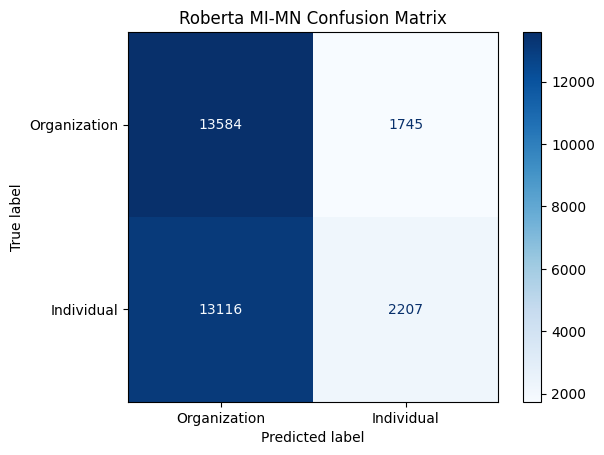

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_classes, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Roberta MI-MN Confusion Matrix")
plt.savefig("Roberta MI-MN set.png", transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
model_saved = RobertaForSequenceClassification.from_pretrained("/content/gdrive/MyDrive/REU/PROJECT/my_awesome_model/checkpoint-13412")


In [ ]:
trainer = Trainer(model = model_saved)
y_pred_test = trainer.predict(tokenized_test)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
y_pred_test =  trainer.predict(tokenized_test)
y_test = test['label']

:)


In [ ]:
predicted_classes_test = np.argmax(y_pred_test.predictions, axis=1)

print(predicted_classes_test)
predicted_classes_test.sum()

[0 1 0 ... 1 1 0]


np.int64(15309)

In [ ]:
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(f1_score(y_test, predicted_classes_test))

0.9855706450770436


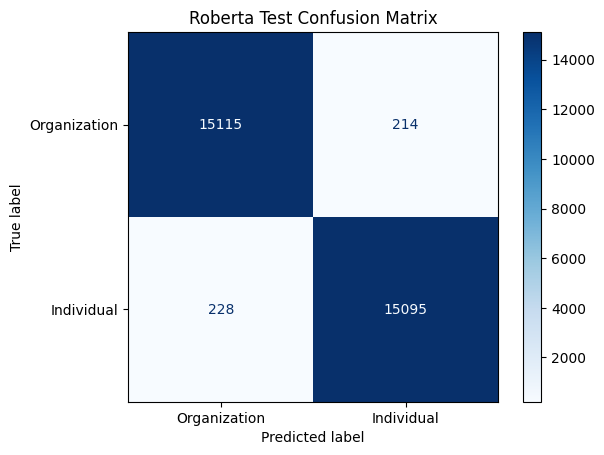

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_classes_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Roberta Test Confusion Matrix")
plt.savefig("Roberta Test set.png", transparent=True, bbox_inches='tight')
plt.show()